# Metric — Length-Retention Curve of Personalisation Success

$$\mathrm{PSR}(f) = \frac{1}{n_f}\sum_{j=1}^{n_f} s_{\sigma(j)}, \qquad n_f = \lceil f N \rceil$$

Test examples are sorted by the word length of the relevant snippet
(`SNIPPET_LEN_UNIT = "words"`), shortest first. At each retention fraction $f$ the
shortest $n_f$ examples are kept and personalisation success is recomputed on
that subset, giving a curve that ends at the full-test PSR when $f = 1$.

---

*Notation:* `q` query · `c+` relevant snippet · `c-` off-topic snippet from the same user · `y+` personalised answer · `y-` general answer


In [3]:
import ast
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    PP_ROOT = Path("/content/drive/MyDrive") / "privacy_perserving_pllm"
else:
    _here = Path(".").resolve()
    PP_ROOT = next(
        (
            p
            for p in [_here, *_here.parents]
            if (p / "v2_personamem_persona_subsets").exists()
            or all((p / d).exists() for d in ("centralised", "evaluation", "fed_grad_avg", "zero_shot"))
        ),
        _here,
    )

SUBSETS_DIR = PP_ROOT / "v2_personamem_persona_subsets"

SUBSETS = ["all_subset"]
MODELS = [
    "centralized_sft",
    "centralized_orpo",
    "centralized_ctx_contrast_orpo",
    "centralized_combined_orpo",
    "centralized_gen_edit_snippet",
    "federated_sft_gradavg",
    "federated_orpo_gradavg",
    "federated_ctx_contrast_orpo_gradavg",
    "federated_combined_orpo_gradavg",
    "federated_gen_edit_gradavg_snippet",
]

DISPLAY_NAMES = {
    "centralized_sft": "SFT",
    "centralized_orpo": "Answer-contrastive",
    "centralized_ctx_contrast_orpo": "Context-contrastive",
    "centralized_combined_orpo": "Dual-contrastive",
    "centralized_gen_edit_snippet": "Draft-revision",
    "federated_sft_gradavg": "SFT",
    "federated_orpo_gradavg": "Answer-contrastive",
    "federated_ctx_contrast_orpo_gradavg": "Context-contrastive",
    "federated_combined_orpo_gradavg": "Dual-contrastive",
    "federated_gen_edit_gradavg_snippet": "Draft-revision",
}

def display_name(model):
    return DISPLAY_NAMES.get(model, model)

JUDGE_EVAL_DIR = "v2_personamem_llm_judge_pref_deepseek"
ADAPTER_EPOCH = 3
SPLIT = "val"

SNIPPET_LEN_UNIT = "words"

RETENTION_FRACTIONS = np.round(np.linspace(0.05, 1.0, 20), 4)

RETAIN_ORDER = "shortest_first"

OUTPUT_DIR = PP_ROOT / "length_retention_judge_deepseek"
FIG_DIR = OUTPUT_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PP_ROOT:", PP_ROOT)
print("Subsets:", SUBSETS)
print("Models:", MODELS)
print("Retain order:", RETAIN_ORDER, "| length unit:", SNIPPET_LEN_UNIT)
print("Output:", OUTPUT_DIR.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PP_ROOT: /content/drive/MyDrive/privacy_perserving_pllm
Subsets: ['all_subset']
Models: ['centralized_sft', 'centralized_orpo', 'centralized_ctx_contrast_orpo', 'centralized_combined_orpo', 'centralized_gen_edit_snippet', 'federated_sft_gradavg', 'federated_orpo_gradavg', 'federated_ctx_contrast_orpo_gradavg', 'federated_combined_orpo_gradavg', 'federated_gen_edit_gradavg_snippet']
Retain order: shortest_first | length unit: words
Output: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek


In [10]:
!ls /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_centralized_gen_edit_snippet

epoch_3  global


In [11]:
def to_binary(series):
    if series.dtype == bool:
        return series.astype(float)
    s = series.astype(str).str.strip().str.lower()
    return s.map(
        {"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0, "1.0": 1.0, "0.0": 0.0}
    ).astype(float)


def snippet_size(raw):
    """Length of a related_conversation_snippet (JSON list of turns or plain text)."""
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return np.nan
    s = str(raw)
    if SNIPPET_LEN_UNIT == "chars":
        return float(len(s))

    turns = None
    try:
        turns = json.loads(s)
    except Exception:
        try:
            turns = ast.literal_eval(s)
        except Exception:
            turns = None

    if isinstance(turns, list):
        dict_turns = [t for t in turns if isinstance(t, dict)]
        if SNIPPET_LEN_UNIT == "turns":
            return float(len(dict_turns))
        text = " ".join(str(t.get("content", "")) for t in dict_turns)
    else:
        text = s
    return float(len(text.split()))


def judge_dir_for(subset):
    """Prefer epoch_<ADAPTER_EPOCH> if present; else the base DeepSeek judge dir."""
    base = PP_ROOT / subset / JUDGE_EVAL_DIR
    candidates = []
    if ADAPTER_EPOCH is not None:
        candidates.append(base / f"epoch_{ADAPTER_EPOCH}")
    candidates.append(base)
    for d in candidates:
        if d.is_dir():
            return d
    return None


_val_len_cache: dict[str, pd.DataFrame] = {}


def val_snippet_lookup(subset):
    """persona_id, ex_id, snippet_size from val.parquet (fallback)."""
    if subset in _val_len_cache:
        return _val_len_cache[subset]
    path = SUBSETS_DIR / subset / "val.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} (needed for snippet length fallback)")
    va = pd.read_parquet(path)
    parts = []
    for _, g in va.groupby("persona_id", sort=False):
        g = g.reset_index(drop=True).assign(ex_id=range(len(g)))
        g["snippet_size"] = g["related_conversation_snippet"].map(snippet_size)
        parts.append(g[["persona_id", "ex_id", "snippet_size"]])
    out = pd.concat(parts, ignore_index=True)
    out["persona_id"] = out["persona_id"].astype(str)
    _val_len_cache[subset] = out
    return out


def load_judge_with_length(subset, model):
    jdir = judge_dir_for(subset)
    if jdir is None:
        print(f"[skip] {subset}: no judge dir under {JUDGE_EVAL_DIR}")
        return None
    path = jdir / f"{model}_{SPLIT}_judge_run2.csv"
    if not path.exists():
        print(f"[skip] missing {path}")
        return None
    df = pd.read_csv(path)
    if "judge_satisfies_pref" not in df.columns:
        print(f"[skip] {path}: no judge_satisfies_pref")
        return None
    print(path)
    d = df.copy()
    d["persona_id"] = d["persona_id"].astype(str)
    d["satisfies"] = to_binary(d["judge_satisfies_pref"])

    if "related_conversation_snippet" in d.columns:
        d["snippet_size"] = d["related_conversation_snippet"].map(snippet_size)
    elif "ex_id" in d.columns:
        look = val_snippet_lookup(subset)
        d = d.merge(look, on=["persona_id", "ex_id"], how="left")
    else:
        print(f"[skip] {subset}/{model}: cannot recover snippet length")
        return None

    d = d.dropna(subset=["satisfies", "snippet_size"]).reset_index(drop=True)
    d["subset"] = subset
    d["model"] = model
    d["judge_dir"] = str(jdir)
    return d[["subset", "model", "persona_id", "satisfies", "snippet_size", "judge_dir"]]


rows = []
for subset in SUBSETS:
    for model in MODELS:
        df = load_judge_with_length(subset, model)
        if df is None or df.empty:
            continue
        rows.append(df)
        print(f"  {subset}/{model}: n={len(df)} | mean sat={df['satisfies'].mean():.4f} | "
              f"snippet {SNIPPET_LEN_UNIT} mean={df['snippet_size'].mean():.1f}")

judge_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
if judge_df.empty:
    raise RuntimeError(
        "No judge rows loaded. Run llm_judge_pref_metric_deepseek.ipynb first, "
        "or adjust SUBSETS / MODELS / ADAPTER_EPOCH."
    )
print("\nLoaded rows:", len(judge_df))
print(judge_df.groupby("model").agg(n=("satisfies", "size"), sat=("satisfies", "mean")).round(4))

/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_llm_judge_pref_deepseek/epoch_3/centralized_sft_val_judge_run2.csv
  all_subset/centralized_sft: n=714 | mean sat=0.4132 | snippet words mean=294.8
/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_llm_judge_pref_deepseek/epoch_3/centralized_orpo_val_judge_run2.csv
  all_subset/centralized_orpo: n=714 | mean sat=0.4048 | snippet words mean=294.8
/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_llm_judge_pref_deepseek/epoch_3/centralized_ctx_contrast_orpo_val_judge_run2.csv
  all_subset/centralized_ctx_contrast_orpo: n=714 | mean sat=0.4146 | snippet words mean=294.8
/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_llm_judge_pref_deepseek/epoch_3/centralized_combined_orpo_val_judge_run2.csv
  all_subset/centralized_combined_orpo: n=714 | mean sat=0.4356 | snippet words mean=294.8
/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personame

In [ ]:
def length_retention_curve(satisfies, lengths, fractions, order="shortest_first"):
    """Satisfaction rate vs fraction retained, ordering by snippet length."""
    if order not in {"shortest_first", "longest_first"}:
        raise ValueError(order)
    idx = np.argsort(lengths, kind="mergesort")
    if order == "longest_first":
        idx = idx[::-1]
    sat_sorted = satisfies[idx]
    n = len(sat_sorted)
    rates = np.empty(len(fractions), dtype=float)
    for i, f in enumerate(fractions):
        k = max(1, int(np.ceil(float(f) * n)))
        rates[i] = sat_sorted[:k].mean()
    return rates

curve_rows = []
for model, g in judge_df.groupby("model", sort=False):
    sat = g["satisfies"].to_numpy(dtype=float)
    lens = g["snippet_size"].to_numpy(dtype=float)
    rates = length_retention_curve(sat, lens, RETENTION_FRACTIONS, order=RETAIN_ORDER)
    for f, r in zip(RETENTION_FRACTIONS, rates):
        curve_rows.append(
            {
                "model": model,
                "retain_order": RETAIN_ORDER,
                "fraction_retained": float(f),
                "satisfaction_rate": float(r),
                "n_total": int(len(g)),
                "n_retained": max(1, int(np.ceil(float(f) * len(g)))),
            }
        )

curve_df = pd.DataFrame(curve_rows)
curve_df["model"] = pd.Categorical(curve_df["model"], categories=MODELS, ordered=True)
curve_df = curve_df.sort_values(["model", "fraction_retained"]).reset_index(drop=True)

out_csv = OUTPUT_DIR / f"length_retention_curves_{RETAIN_ORDER}.csv"
curve_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

piv = curve_df.pivot_table(
    index="fraction_retained", columns="model", values="satisfaction_rate"
)
print(piv.round(3).to_string())

Saved: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek/length_retention_curves_shortest_first.csv
model              federated_sft_gradavg  federated_orpo_gradavg  federated_ctx_contrast_orpo_gradavg  federated_combined_orpo_gradavg  federated_gen_edit_gradavg_snippet
fraction_retained                                                                                                                                                         
0.05                               0.250                   0.306                                0.417                            0.250                               0.306
0.10                               0.222                   0.236                                0.306                            0.208                               0.208
0.15                               0.241                   0.306                                0.296                            0.231                               0.259
0.20            

/tmp/ipykernel_5277/2168690094.py:48: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = curve_df.pivot_table(


Saved: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek/figs/length_retention_shortest_first_fed.png


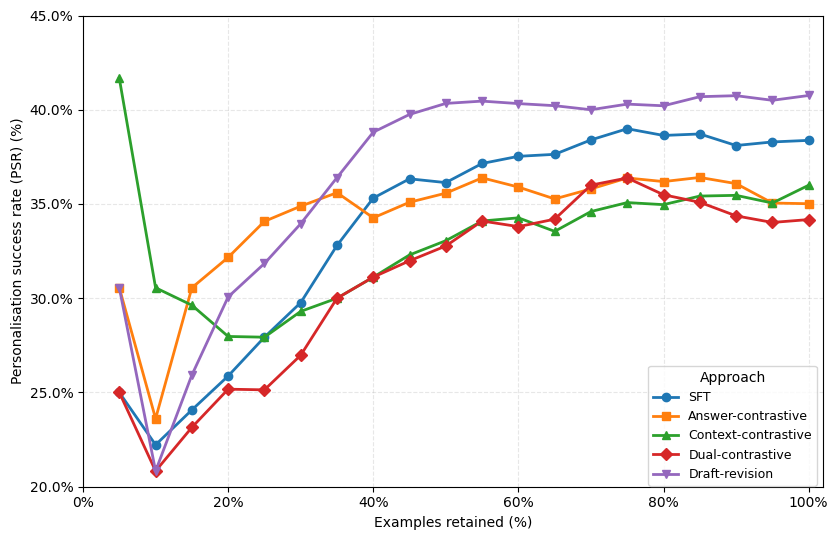

In [ ]:
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for k, model in enumerate(MODELS):
    sub = curve_df[curve_df["model"] == model]
    if sub.empty:
        continue
    ax.plot(
        sub["fraction_retained"].values,
        sub["satisfaction_rate"].values,
        marker=markers[k % len(markers)],
        linewidth=2,
        markersize=6,
        label=display_name(model),
    )

ax.set_xlabel("Examples retained (%)")
ax.set_ylabel("Personalisation success rate (PSR) (%)")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(alpha=0.3, linestyle="--")
ax.set_ylim(0.20, 0.45)
ax.set_axisbelow(True)
ax.legend(title="Approach", fontsize=9, bbox_to_anchor=(1, 0.27), loc="upper right")
fig.tight_layout()

fig_path = FIG_DIR / f"length_retention_{RETAIN_ORDER}_fed.png"
fig.savefig(fig_path, dpi=500, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()
plt.close(fig)

Saved: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek/length_retention_curves_longest_first.csv
Saved: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek/figs/length_retention_longest_first.png


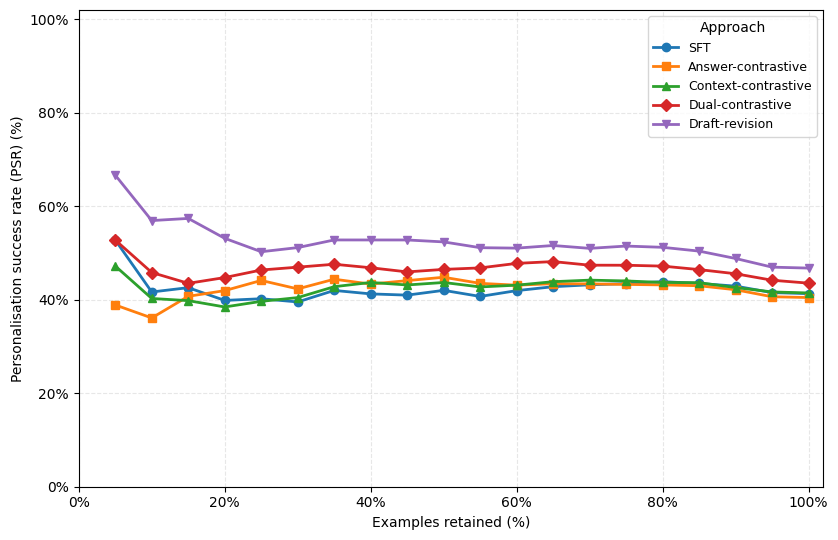

In [ ]:
alt_order = "longest_first" if RETAIN_ORDER == "shortest_first" else "shortest_first"

alt_rows = []
for model, g in judge_df.groupby("model", sort=False):
    sat = g["satisfies"].to_numpy(dtype=float)
    lens = g["snippet_size"].to_numpy(dtype=float)
    rates = length_retention_curve(sat, lens, RETENTION_FRACTIONS, order=alt_order)
    for f, r in zip(RETENTION_FRACTIONS, rates):
        alt_rows.append(
            {
                "model": model,
                "retain_order": alt_order,
                "fraction_retained": float(f),
                "satisfaction_rate": float(r),
                "n_total": int(len(g)),
                "n_retained": max(1, int(np.ceil(float(f) * len(g)))),
            }
        )

alt_df = pd.DataFrame(alt_rows)
alt_df["model"] = pd.Categorical(alt_df["model"], categories=MODELS, ordered=True)
alt_df = alt_df.sort_values(["model", "fraction_retained"]).reset_index(drop=True)
alt_csv = OUTPUT_DIR / f"length_retention_curves_{alt_order}.csv"
alt_df.to_csv(alt_csv, index=False)
print("Saved:", alt_csv)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for k, model in enumerate(MODELS):
    sub = alt_df[alt_df["model"] == model]
    if sub.empty:
        continue
    ax.plot(
        sub["fraction_retained"].values,
        sub["satisfaction_rate"].values,
        marker=markers[k % len(markers)],
        linewidth=2,
        markersize=6,
        label=display_name(model),
    )

ax.set_xlabel("Examples retained (%)")
ax.set_ylabel("Personalisation success rate (PSR) (%)")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(title="Approach", fontsize=9, bbox_to_anchor=(1, 1), loc="upper right")
fig.tight_layout()

alt_fig = FIG_DIR / f"length_retention_{alt_order}.png"
fig.savefig(alt_fig, dpi=200, bbox_inches="tight")
print("Saved:", alt_fig)
plt.show()
plt.close(fig)

In [ ]:
def slope_summary(df, order_name):
    rows = []
    for model, g in df.groupby("model", sort=False):
        g = g.sort_values("fraction_retained")
        f_lo = float(g["fraction_retained"].iloc[0])
        sat_lo = float(g["satisfaction_rate"].iloc[0])
        sat_hi = float(g.loc[g["fraction_retained"] == 1.0, "satisfaction_rate"].iloc[0])
        rows.append(
            {
                "model": model,
                "retain_order": order_name,
                "sat_at_min_retention": sat_lo,
                "min_fraction": f_lo,
                "sat_at_full": sat_hi,
                "delta_min_minus_full": sat_lo - sat_hi,
            }
        )
    return pd.DataFrame(rows)


summary = pd.concat(
    [slope_summary(curve_df, RETAIN_ORDER), slope_summary(alt_df, alt_order)],
    ignore_index=True,
)
summary_path = OUTPUT_DIR / "length_retention_slope_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)
print(summary.round(4).to_string(index=False))

/tmp/ipykernel_5277/1027408179.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model, g in df.groupby("model", sort=False):


Saved: /content/drive/MyDrive/privacy_perserving_pllm/length_retention_judge_deepseek/length_retention_slope_summary.csv
                        model   retain_order  sat_at_min_retention  min_fraction  sat_at_full  delta_min_minus_full
              centralized_sft shortest_first                0.3889          0.05       0.4132               -0.0243
             centralized_orpo shortest_first                0.3889          0.05       0.4048               -0.0159
centralized_ctx_contrast_orpo shortest_first                0.3889          0.05       0.4146               -0.0257
    centralized_combined_orpo shortest_first                0.3056          0.05       0.4356               -0.1300
 centralized_gen_edit_snippet shortest_first                0.4167          0.05       0.4678               -0.0511
              centralized_sft  longest_first                0.5278          0.05       0.4132                0.1146
             centralized_orpo  longest_first                0.3889 